# Unsupervised Learning - Exercise

```In this exercise you will experience with K-Means, and PCA, and will do some use of them for handling practical problems.```

~```Gilad Royz & Itai Haran```

# Part 1 - Clustering

```In this question you are asked to examine the 3 clustering algorithms: KMeans, DBscan and GaussianMixture.```

```You will have to generate manipulative datasets, and demonstrate the weaknesses of each method. That is, for each one of the clustering methods, generate a dataset such that one of the methods will fail, and the others will not.
Deal with the model's hyper parameters, and conclude for yourself how sensitive they are.```

```For each dataset draw your results using your favorite visualization tool.```

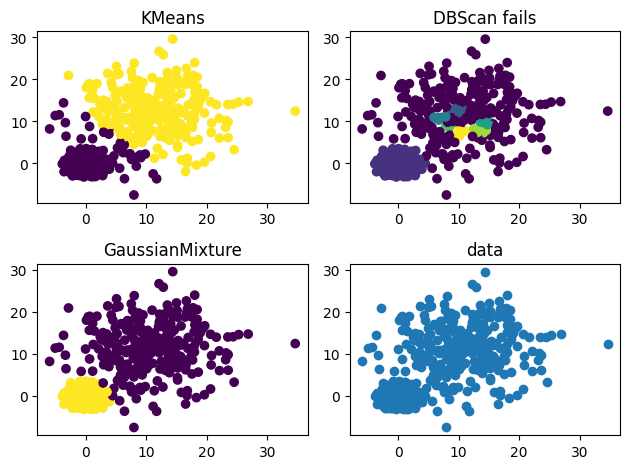

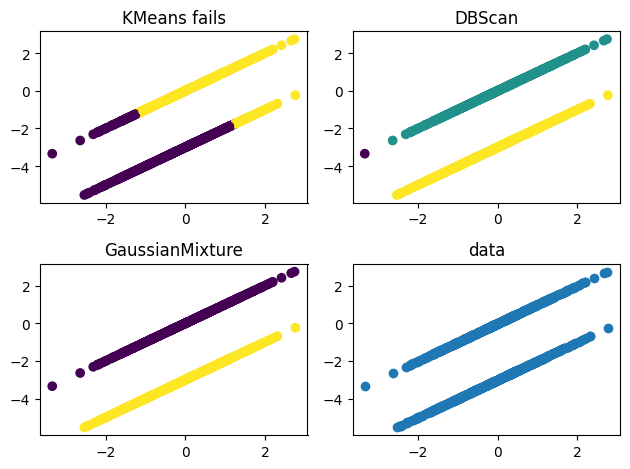

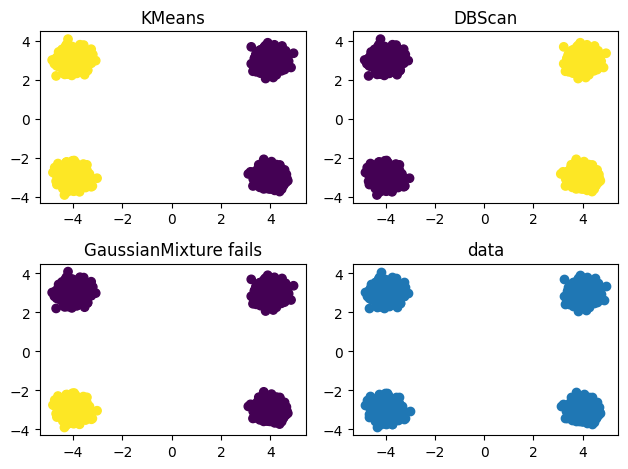

In [163]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

random_generator = np.random.default_rng(1)

def plot_algos(models, data, fails): #{name: model}
    fig, axs = plt.subplots(2, 2)
    axs[1][1].set_title("data")
    axs[1][1].scatter(data[:, 0], data[:, 1])
    for i, model in enumerate(models):
        a = i // 2
        b = i % 2
        labels = models[model].fit_predict(data)
        if model == fails:
            axs[a][b].set_title(model + " fails")
        else:
            axs[a][b].set_title(model)
        axs[a][b].scatter(data[:, 0], data[:, 1], c=labels)
    plt.tight_layout()

dense_noise = random_generator.normal(0, 1, (5000, 2))
sparse_noise = random_generator.normal(0, 6, (300, 2))

dense_blob = np.zeros((1,2)) + dense_noise
sparse_blob = np.array([11, 11]).reshape((1,2)) + sparse_noise

dbs_fails = np.concatenate((dense_blob, sparse_blob))

km = KMeans(n_clusters=2)
dbs = DBSCAN(eps=1, min_samples=7)
gm = GaussianMixture(n_components=2, init_params='random')


plot_algos({"KMeans": km, "DBScan": dbs, "GaussianMixture": gm}, dbs_fails, "DBScan")



small_gaussian = random_generator.multivariate_normal((0,0), ((1,1),(1,1)), 500)
large_gaussian = random_generator.multivariate_normal((0,-3), ((1,1),(1,1)), 500)

km_fails = np.concatenate((small_gaussian, large_gaussian))

km = KMeans(n_clusters=2)
dbs = DBSCAN(eps=0.8, min_samples=5)
gm = GaussianMixture(n_components=2)


plot_algos({"KMeans": km, "DBScan": dbs, "GaussianMixture": gm}, km_fails, "KMeans")

gauss_1 = random_generator.normal([-4, 3], 0.3, size=(500,2))
gauss_2 = random_generator.normal([-4,-3], 0.3, size=(500,2))
gauss_3 = random_generator.normal([4,3], 0.3, size=(500,2))
gauss_4 = random_generator.normal([4,-3], 0.3, size=(500,2))

blob_1 = np.concatenate((gauss_1, gauss_2))
blob_2 = np.concatenate((gauss_3, gauss_4))

gm_fails = np.concatenate((blob_1, blob_2))

km = KMeans(n_clusters=2)
dbs = DBSCAN(eps=5, min_samples=5)
gm = GaussianMixture(n_components=2, init_params='random')

plot_algos({"KMeans": km, "DBScan": dbs, "GaussianMixture": gm}, gm_fails, "GaussianMixture")



    






```Answer the following questions based on what you learned from the previous question:```
- ```Which method is easiest to use?```
- ```Which method is the fastest to use?```

```We will now use K-Means to quantize image colors:```

```First load the given celebrity image from the image folder (can be found in:```
https://drive.google.com/file/d/1nUk_Q-ahhUrjmUl_sM9ovb84DybuaQCe/view?usp=sharing)

In [2]:
import cv2

In [3]:
img = cv2.imread('images/Alicia Vikander/1.jpg')[:,:,::-1]
img_array = np.array(img)

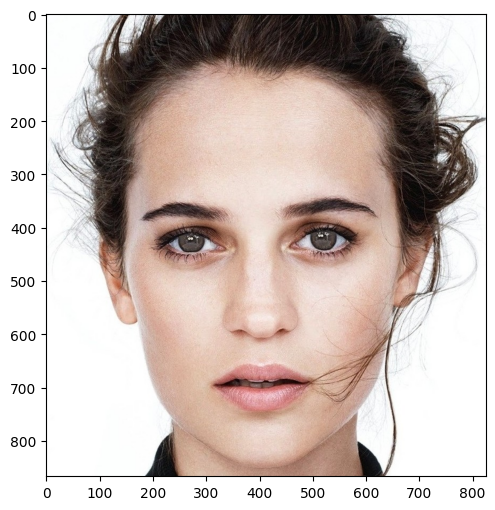

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(img_array)

```Every pixel in the image is composed of three colors (Red, Green, Blue), and therefore, every pixel is a vector: (r,g,b).```
```Create a list of every color pixel in the image: (array.reshape will work)```

In [16]:
img_data = img_array.reshape(867*825, 3)

array([[254, 255, 255],
       [254, 255, 255],
       [254, 255, 255],
       [254, 255, 255],
       [253, 254, 255],
       [253, 254, 255]], dtype=uint8)

```Train a K-Means model with k=10 on the list of colors:```

In [11]:
from sklearn.cluster import KMeans

In [29]:
km = KMeans(n_clusters=10)
km_img = km.fit(img_data)


(715275, 3)


```Now replace every color vector with the vector of centroid bector of it's cluster.```
```rebuild the image and plot it. How is it compared to the original?```

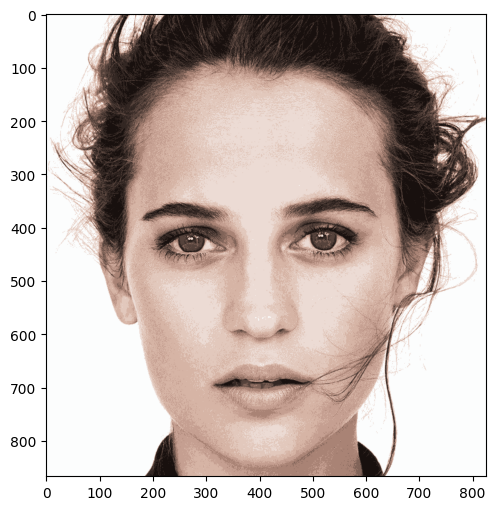

In [33]:
centroids = km_img.cluster_centers_[km_img.predict(img_data)]
centroids = centroids.astype(int)
central_img = centroids.reshape(867, 825, 3)
plt.figure(figsize=(6,6))
plt.imshow(central_img)

```Train K-Means model with k=2,...,15, and plot the "within-cluster sum-of-squares criterion"```($R_k$)``` for all the k's.```

```(reduce the n_init if it takes too much time)```

(Explain on $R_k$ can be found in: https://scikit-learn.org/stable/modules/clustering.html#k-means)

```Can we conclude "how many clusters" are there, from the graph?```

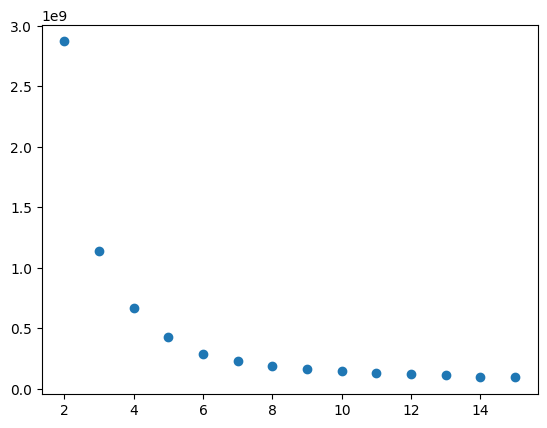

In [ ]:
rks = [] 
ks = range(2,16)
for k in ks:
    km = KMeans(n_clusters=k)
    km_img = km.fit(img_data)
    rks.append(km_img.inertia_)
plt.figure()
plt.scatter(ks, rks)

# around 7 clusters

# part 2 - Dimensionality reduction

```The goal of this part is to experience with some basic features of PCA, and have a notion about the capabilities, and uses of this method.```

```We will look on facial images of 3 celebrities, and use PCA to extract facial patterns from images.```
```We then try to use those patterns to build a classifier that can distinguish the 3 celebrities.```

In [38]:
celebs = ['Alicia Vikander', 'Amy Adams', 'Andy Serkis']
# images folder in: https://drive.google.com/file/d/1nUk_Q-ahhUrjmUl_sM9ovb84DybuaQCe/view?usp=sharing

In [59]:
def read_gray_image(path):
    """
    return array with:
    0-axis: height
    1-axis: width
    2-axis: color(rgb)
    """
    return cv2.cvtColor(cv2.imread(path)[:,:,::-1], cv2.COLOR_RGB2GRAY)

```First we load the face images:```

In [91]:
import os

face_imgs = []
labels = []
for j, c in enumerate(celebs):
    
    dir_path = 'images/{}/'.format(c)
    dir_file_paths = [dir_path + i for i in os.listdir(dir_path)]
    
    temp_imgs = [read_gray_image(dir_path + i) for i in os.listdir(dir_path)]
    
    labels += [j]*len(dir_file_paths)
    face_imgs += [read_gray_image(i) for i in dir_file_paths]

```For later steps, we would like to resize all the images to have the same width x height. It is best to choose new shape that least distort the images.```

```Plot the shapes of all the images on the "width", "height" plane: (What does that remind you of?)```

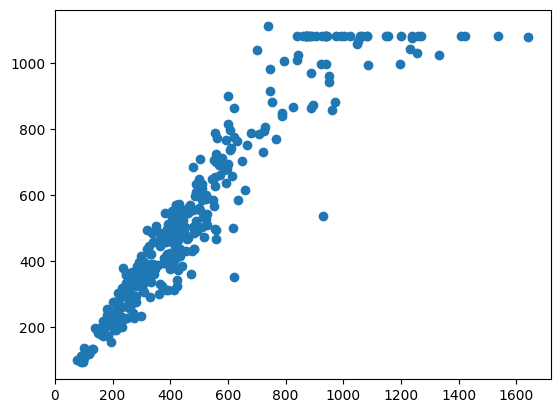

In [92]:
plt.figure()
widths = [] 
heights = [] 
for im in face_imgs:
    h, w = im.shape
    widths.append(w)
    heights.append(h)
plt.scatter(widths, heights)

```Now on the same plot, draw the point of the "avarage shape". Is it looks like it represents the trend?```

```Resize all the face images to have the "avarage shape." ( cv2.resize will work)```

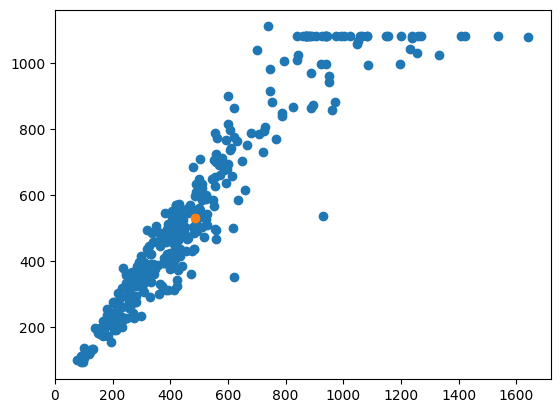

In [93]:
mw = np.mean(widths).astype(int)
mh = np.mean(heights).astype(int)
plt.scatter(widths, heights)
plt.scatter(mw, mh)
for i, im in enumerate(face_imgs):
    face_imgs[i] = cv2.resize(im, (mw, mh))


```Flatten all the images into vectors, and split them randomly to train and test groups (with ratio (0.7, 0.3)).```

In [69]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [94]:
imgs_data = np.array(face_imgs).reshape(357, 530*485)
x_train, x_test, y_train, y_test = train_test_split(imgs_data, labels, test_size=0.3, random_state=1)

```Now train a PCA model with n_components=10 on the train set. How much variance(in %) the 10 components explain? is it good compared to the dimention of the vectors?```

In [95]:
pca = PCA(n_components=10).fit(x_train)
print(100*pca.explained_variance_ratio_)

[25.00607069  9.24671193  7.89932289  5.30677806  3.98707504  3.2634175
  2.73343182  2.62283056  1.95157566  1.81457714]


```Take the 10 component vectors of the model, reshape them to the image shape, and plot all of them:```

It looks something like that:
![image.png](attachment:image.png)

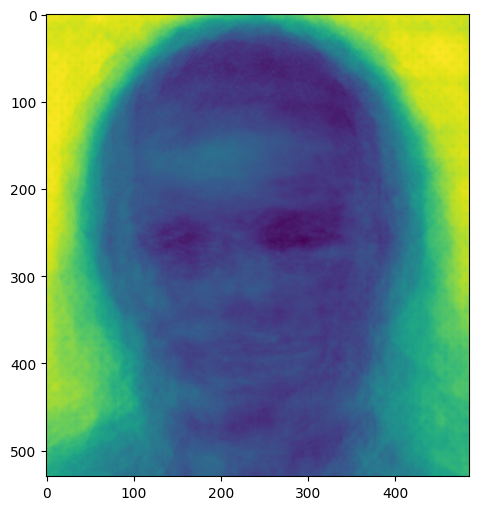

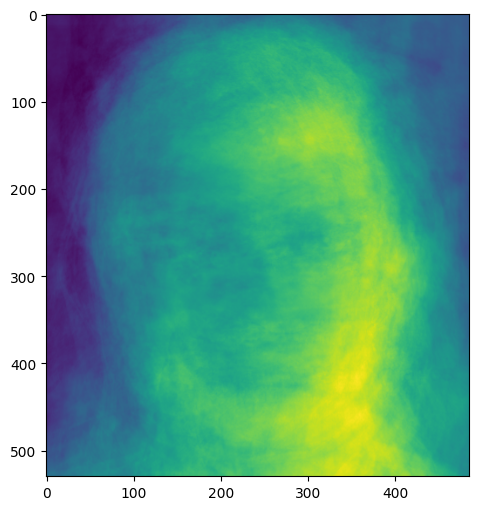

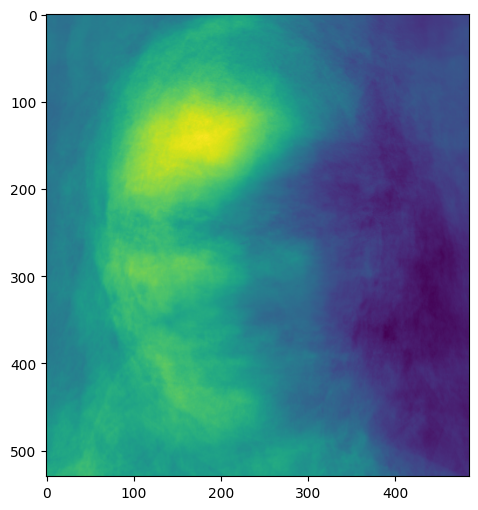

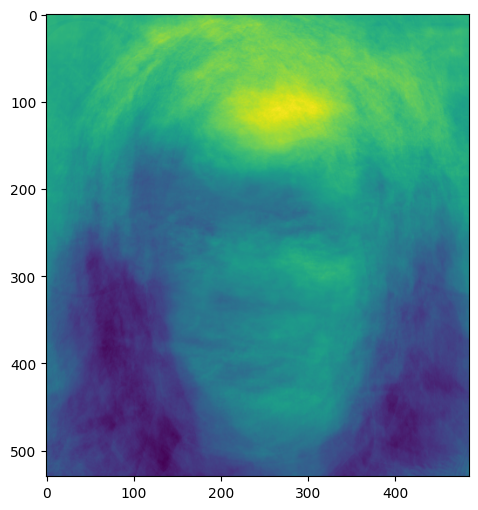

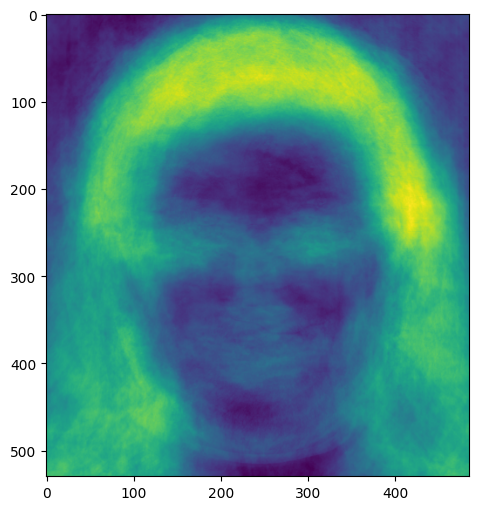

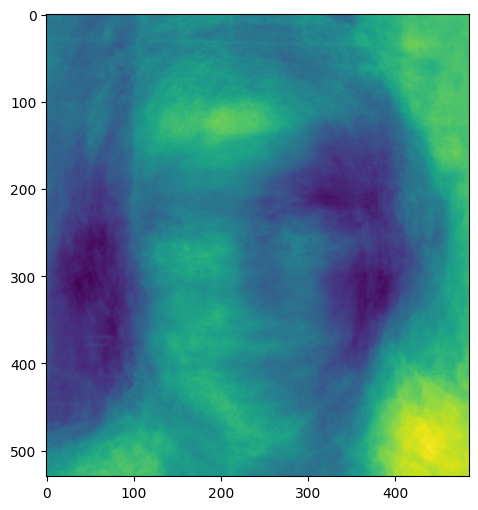

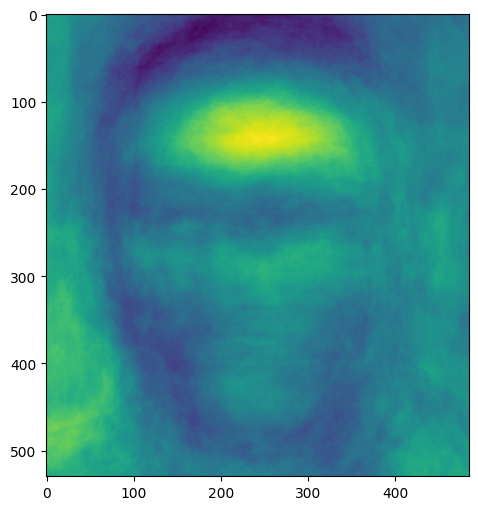

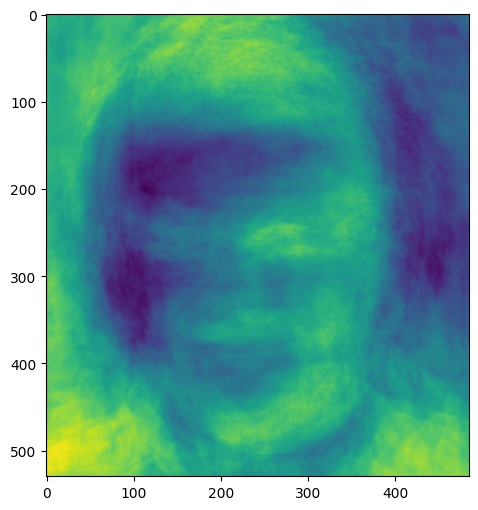

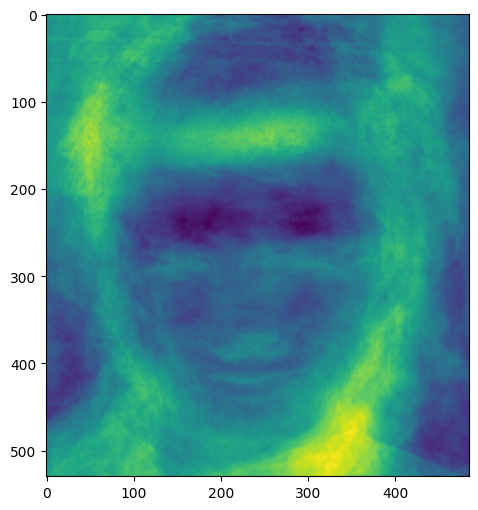

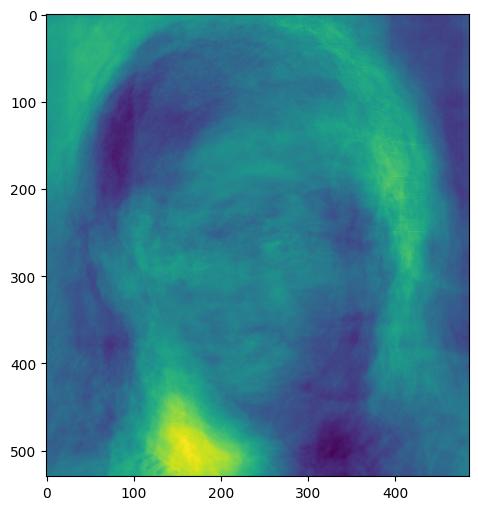

In [96]:
for new_img in pca.components_.reshape(10, 530, 485):
    plt.figure(figsize=(6,6))
    plt.imshow(new_img)

```The "faces" that we got, can roוghly be refered to as the "face patterns" that are the most dominant in the images. can you make sense of the patterns?```

```Notice that if we transform an image to the low dimension and then inverse transform it back, we actually find the "best combination of the patterns" that reconstract out image```

```Now make a PCA model with n_components=10 for the images of every celebrity in the train set (pca_1, pca_2, pca_3). And Then:```

- ```Take all the vectors from the test set.```
- ```Transform them to the low dimension.```
- ```Inverse transform them back to original dimension.```
- ```Compute "mean square error" (MSE) between the original vectors to the reconstructed version of themselves.```
- ```For every vector, mark the PCA model that gave the smallest MSE. (as prediction)```
- ```Print the "confusion matrix" of the prediction.``` (https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)

[[21 11  1]
 [ 7 32  1]
 [ 8  4 23]]


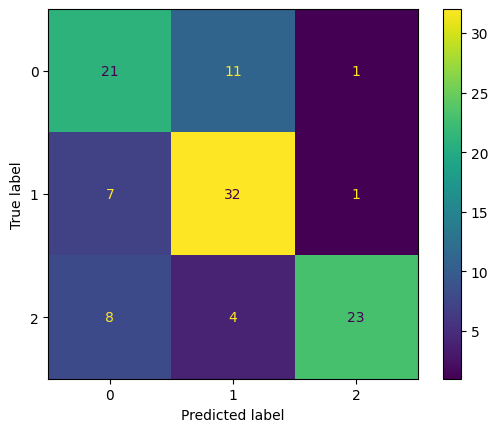

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

predictions = []
inv_trans_tests = [] 
pcas = [] 
for i in range(3):
    pca = PCA(n_components=10).fit(x_train[y_train == i])
    pcas.append(pca)
    trans_test = pca.transform(x_test)
    inv_trans_tests.append(pca.inverse_transform(trans_test))

for i, im in enumerate(x_test):
    mses = [] 
    for j in range(3):
        mses.append(np.mean((im - inv_trans_tests[j][i])**2))
    predictions.append(np.argmin(mses))

disp = ConfusionMatrixDisplay.from_predictions(y_test, predictions)
print(disp.confusion_matrix)


```Is it work well? If yes, try to explain why.```

It does, since each pca only reconstructs the image well if it's similar to what it was trained on

## Bonus (5 pts)

```Perform the prediction process with PCA models with n_components=[1,10,20,30,40,50,60,70].```

[[19 10  4]
 [11 26  3]
 [10  4 21]]
[[21 11  1]
 [ 7 32  1]
 [ 7  4 24]]
[[24  8  1]
 [ 4 35  1]
 [ 6  3 26]]
[[23  8  2]
 [ 7 32  1]
 [ 5  4 26]]
[[24  7  2]
 [ 8 31  1]
 [ 5  3 27]]
[[28  4  1]
 [ 7 32  1]
 [ 5  3 27]]
[[28  4  1]
 [ 7 32  1]
 [ 6  2 27]]
[[28  4  1]
 [ 7 32  1]
 [ 6  4 25]]


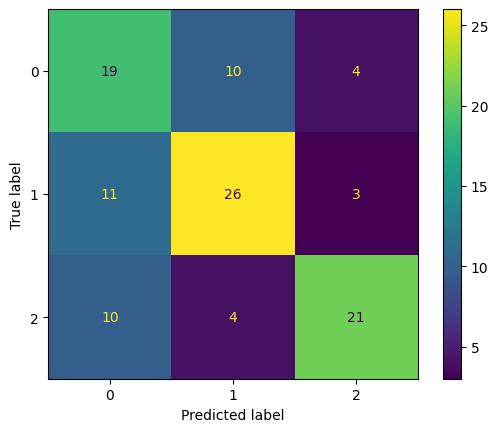

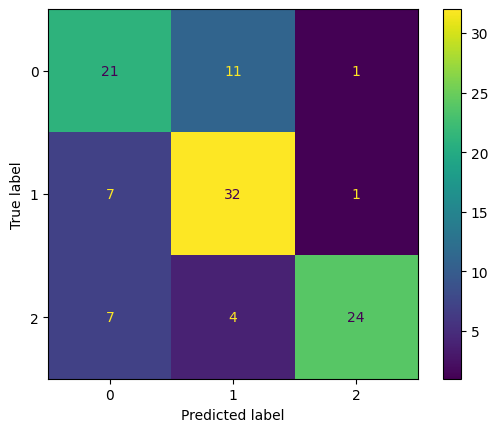

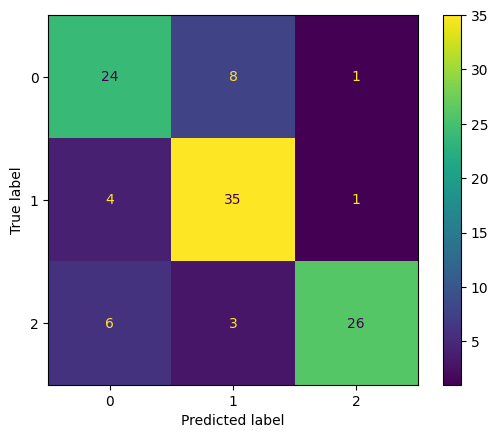

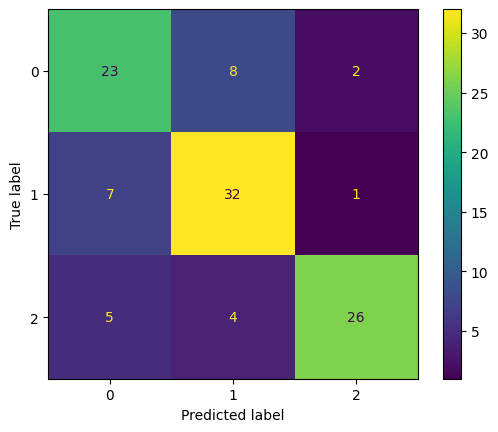

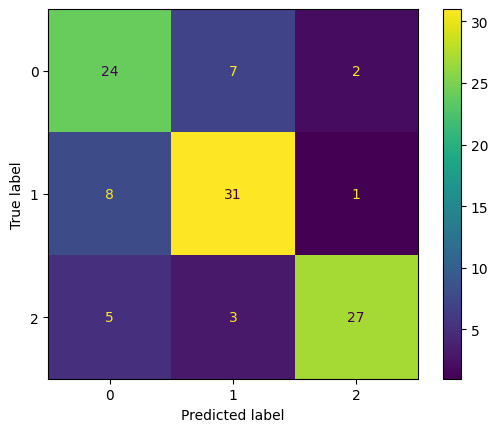

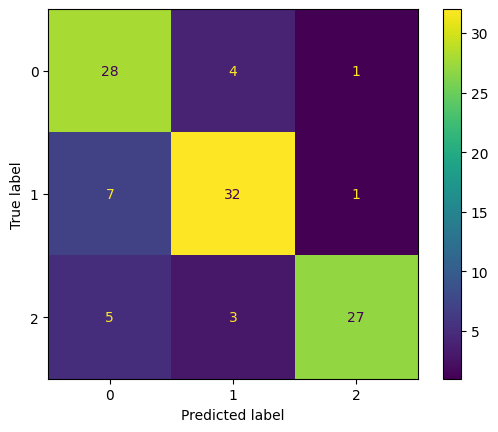

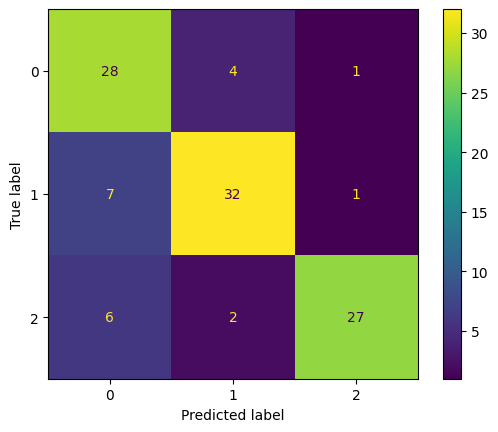

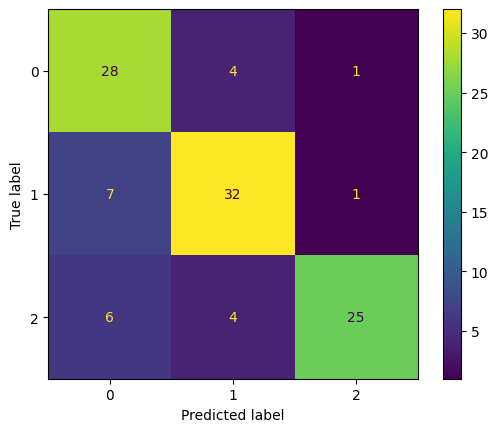

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)
accs = []
n_comps = [1,10,20,30,40,50,60,70]
for ncomp in n_comps:
    predictions = []
    inv_trans_tests = [] 
    pcas = [] 
    for i in range(3):
        pca = PCA(n_components=ncomp).fit(x_train[y_train == i])
        pcas.append(pca)
        trans_test = pca.transform(x_test)
        inv_trans_tests.append(pca.inverse_transform(trans_test))

    for i, im in enumerate(x_test):
        mses = [] 
        for j in range(3):
            mses.append(np.mean((im - inv_trans_tests[j][i])**2))
        predictions.append(np.argmin(mses))
    accs.append(np.mean(predictions == y_test))
    disp = ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    print(disp.confusion_matrix)


```Plot the accuracy of the models. what is the trend of the performance when n_components increases? Is it what you expected? try to explain.```

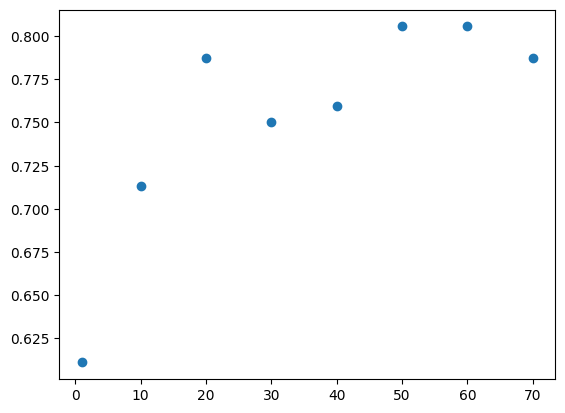

In [ ]:
plt.figure()
plt.scatter(n_comps, accs)